# **EQUIPO LFM** | Aprendizaje automatico

## **Introducción**

El presente trabajo tiene como objetivo desarrollar una metodología analítica que permita predecir el ancho del pétalo de la especie botánica Iris, sobre la base de los datos de tres de sus subespecies, utilizando KNN y regresión lineal.

Se evalúan los resultados de los entrenamientos realizados en una, dos y tres dimensiones, explorando las diferentes combinaciones que el dataset de origen permite. Esto busca obtener un mayor entendimiento de cómo la selección dimensional y la correlación entre variables afectan la precisión de los modelos obtenidos.

Es importante mencionar que, con fines pedagógicos que incluyen la exploración metodológica y la transmisión horizontal de conocimiento entre los miembros del equipo, este estudio excede los requerimientos mínimos planteados por la cátedra sin alejarse del eje temático central.

## Metodología

(Meto: euclidiana (Minkowski p=2 por defecto en Scikit learn)

*Criterio de Selección de Hiperparámetros Basado en Estabilidad Local:*
En la optimización del modelo KNN, la práctica convencional dicta la selección del hiperparámetro k que minimiza la función de pérdida, en este caso, el Error Cuadrático Medio ($MSE$). No obstante, para garantizar la generalización del modelo y mitigar la sensibilidad ante el ruido estocástico de la muestra de entrenamiento, este estudio implementa un criterio de Zona de Estabilidad Analítica.

*Definición del Umbral de Estabilidad (ε):*
Se define un umbral de tolerancia ε para el gradiente discreto del error local. El valor se establece en $0.000125$, derivado de una partición diádica de la unidad de resolución mínima del fenómeno observado. Dado que el rango dinámico del MSE se sitúa en el orden de 10^(-3) (0.001, 0.009), la elección de ε se justifica bajo los siguientes pilares técnicos:
- Resolución de Escala y Sensibilidad:
Al fijar ε = 1.25 * 10^(-4), se exige que la variación punto a punto entre k_i y k_(i+1) sea una magnitud de orden inferior al error base observado. Esto asegura que la zona identificada sea una "meseta" de convergencia y no una fluctuación marginal.
- Partición Diádica y Flexibilidad Computacional: El umbral se calcula mediante la relación ε = U_s/2^n donde U_s es la primera cifra significativa de la cota inferior del error ($0.001$) y $n=3$. Esta estructura de potencias de 2 facilita una búsqueda hiperparamétrica sistemática: permite una contracción o expansión del margen de estabilidad de forma geométrica, manteniendo la simetría en la granularidad del análisis.
- ⁠Análisis de Rango Dinámico: El umbral seleccionado representa aproximadamente el $1.56\%$ del rango total de error observado Range_MSE = 0.0080. En términos de robustez, una variabilidad inferior al 2% dentro de una secuencia continua de k define una región de baja varianza, lo cual es indicativo de un equilibrio óptimo en el compromiso sesgo-varianza (Bias-Variance Tradeoff).

*Identificación de Islas de Estabilidad:*
Si bien se indica el valor de K asociado al menor MSE en el gráfico que se realiza en cada caso, en lugar de seleccionar dicho mínimo global absoluto -que frecuentemente reside en valles de alta sensibilidad-, el algoritmo implementado busca la “Isla de K contínuos de mayor Estabilidad“ dentro del conjunto de candidatos que satisfacen :
| MSE_k - MSE_k+1 | < ε
Este enfoque garantiza que el valor de k óptimo pertenezca a un entorno donde pequeñas variaciones en el hiperparámetro no deriven en degradaciones abruptas del rendimiento, asegurando así una mayor confiabilidad en el despliegue del modelo sobre datos no observados.


## Bibliotecas

In [1512]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import ShuffleSplit, cross_val_score
from mpl_toolkits.mplot3d import Axes3D


## Funciones

In [1513]:
# @title
# funciones

# Optimización de K: Error vs. Número de Vecinos
def koptimomse(X_train, X_test, y_train, y_test):
  k_values = range(1, 21) # Probamos k desde 1 hasta 20
  errores_mse = []

  for k in k_values:
      # Entrenar modelo con el k actual
      modelo = KNeighborsRegressor(n_neighbors=k)
      modelo.fit(X_train, y_train)

      # Predecir y calcular el error
      predicciones = modelo.predict(X_test)
      mse = mean_squared_error(y_test, predicciones)
      errores_mse.append(mse)

  # Guardar resultados y graficar
  resultados = pd.DataFrame({'k': k_values, 'MSE': errores_mse})

  plt.figure(figsize=(10, 6))
  plt.plot(k_values, errores_mse, marker='o', linestyle='--', color='darkblue')

  # Estética del gráfico
  plt.title('Optimización de K: Error vs. Número de Vecinos', fontsize=14)
  plt.xlabel('Valor de K (n_neighbors)', fontsize=12)
  plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
  plt.xticks(k_values) # Para ver todos los números del 1 al 20
  plt.grid(True, alpha=0.3)

  # Marcar el punto óptimo
  min_mse = min(errores_mse)
  best_k = k_values[errores_mse.index(min_mse)]
  plt.annotate(f'K para MSE mínimo teórico= {best_k}',
              xy=(best_k, min_mse),
              xytext=(best_k + 1, min_mse + 0.01),
              arrowprops=dict(facecolor='black', shrink=0.05))

  plt.show()
  print(f"El valor de K teórico con MSE mínimo es: {best_k}")
  return resultados, best_k


# Búsqueda del K con menor promedio de residuos
def koptimo_residuos(zona_estable, X_train, X_test, y_train, y_test):

  residuos_resultados = {}

  for i in range(len(zona_estable)):
      best_k = zona_estable[i]
      knn = KNeighborsRegressor(n_neighbors= best_k)
      knn.fit(X_train, y_train)
      y_pred = knn.predict(X_test)
      residuos = y_test - y_pred
      residuos_mean = residuos.mean()
      print(f"K: {best_k} | Prom residuos: {residuos_mean}")
      # print(f"Prom residuos: {residuos_mean}")
      residuos_resultados[best_k] = residuos_mean
  print("\n----------------\n")
  # Encontrar la clave asociada al valor mínimo
  best_k = min(residuos_resultados, key=residuos_resultados.get)

  # Obtener el valor mínimo usando esa clave
  min_residuo = residuos_resultados[best_k]

  print(f"Clave (K) con residuo mínimo: {best_k}")
  print(f"Valor del residuo mínimo: {min_residuo}")

  return best_k, min_residuo



# Cálculo de métricas de regresion
def regre(y_test, y_pred):
  # 1. Cálculo de métricas
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  return mse, r2


# Grafico de regresion con resultados
def regrapho(y_test, y_pred):
  # llamado a funcion 'regre' para obtener metricas
  mse, r2 = regre(y_test, y_pred)

  # 2. Generación del gráfico
  plt.figure(figsize=(8, 6))
  plt.scatter(y_test, y_pred, alpha=0.7, color='teal')
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)

  # Configuración de etiquetas
  plt.xlabel('Valores Reales')
  plt.ylabel('Predicciones')
  plt.title('Real vs Predicho (KNN Regressor)')

  # 3. Agregar el cuadro de texto "dentro" del gráfico (esquina inferior derecha)
  texto_metricas = f"MSE: {mse:.4f}\nR²: {r2:.4f}"

  # Usamos plt.gca().text para posicionar el texto
  # transform=plt.gca().transAxes asegura que (1,0) sea la esquina inferior derecha exacta
  plt.gca().text(0.95, 0.05, texto_metricas,
                transform=plt.gca().transAxes,
                fontsize=11,
                verticalalignment='bottom',
                horizontalalignment='right',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='teal'))

  plt.show()
  print(f"Mean Square Error: {mse}")
  print(f"R^2: {r2}")
  return mse, r2


# Función para Línea de Regresión 2D (Experimentos con 1 variable)
def graficar_linea_2d_knn(modelo, X, y, nombres_cols):
    """
    Genera un gráfico 2D con los puntos reales y la línea de predicción escalonada de KNN.
    X: DataFrame o Array con exactamente 1 columna.
    """
    plt.figure(figsize=(10, 6))

    # Datos reales
    x_data = X.iloc[:, 0] if hasattr(X, 'iloc') else X.flatten()
    plt.scatter(x_data, y, color='gray', alpha=0.5, label='Datos Reales')

    # Crear línea de predicción suave
    x_range = np.linspace(x_data.min(), x_data.max(), 500).reshape(-1, 1)

    # Manejo de nombres de columnas si es necesario
    if hasattr(X, 'columns'):
        import pandas as pd
        x_range_df = pd.DataFrame(x_range, columns=X.columns)
        y_pred = modelo.predict(x_range_df)
    else:
        y_pred = modelo.predict(x_range)

    plt.plot(x_range, y_pred, color='red', linewidth=2, label='Línea de Regresión KNN')

    plt.xlabel(nombres_cols[0])
    plt.ylabel(nombres_cols[1])
    plt.title('Análisis de Regresión KNN (2D)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Función para Superficie 3D (Experimentos con 2 variables)
def graficar_superficie_3d_knn(modelo, X, y, nombres_cols):
    """
    Genera un gráfico 3D con los puntos reales y la superficie de predicción de KNN.
    X: DataFrame o Array con exactamente 2 columnas.
    y: Series o Array con la variable objetivo.
    nombres_cols: Lista con [Nombre X1, Nombre X2, Nombre Y].
    """
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Datos reales
    # Si X es DataFrame, usamos .iloc para evitar errores de índice
    x1_data = X.iloc[:, 0] if hasattr(X, 'iloc') else X[:, 0]
    x2_data = X.iloc[:, 1] if hasattr(X, 'iloc') else X[:, 1]
    ax.scatter(x1_data, x2_data, y, c='teal', marker='o', alpha=0.6, label='Datos Reales')

    # 2. Crear malla para la superficie de predicción
    x1_range = np.linspace(x1_data.min(), x1_data.max(), 30)
    x2_range = np.linspace(x2_data.min(), x2_data.max(), 30)
    X1_mesh, X2_mesh = np.meshgrid(x1_range, x2_range)

    # Crear set de prueba para la malla
    malla_input = np.c_[X1_mesh.ravel(), X2_mesh.ravel()]

    # Predicción sobre la malla
    # Nota: Si el modelo se entrenó con nombres de columnas, convertimos a DF
    if hasattr(X, 'columns'):
        import pandas as pd
        malla_df = pd.DataFrame(malla_input, columns=X.columns)
        Z_mesh = modelo.predict(malla_df).reshape(X1_mesh.shape)
    else:
        Z_mesh = modelo.predict(malla_input).reshape(X1_mesh.shape)

    # 3. Graficar superficie
    surf = ax.plot_surface(X1_mesh, X2_mesh, Z_mesh, cmap='viridis', alpha=0.4, edgecolor='none')

    ax.set_xlabel(nombres_cols[0])
    ax.set_ylabel(nombres_cols[1])
    ax.set_zlabel(nombres_cols[2])
    plt.title(f'Superficie de Regresión KNN (3D)')
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    plt.show()


def graficar_histograma_residuos(y_real, y_pred):
    """
    Grafica la distribución de los errores (residuos).
    y_real: Valores verdaderos del set de test.
    y_pred: Predicciones hechas por el modelo KNN.
    """
    residuos = y_real - y_pred

    plt.figure(figsize=(10, 6))
    sns.histplot(residuos, kde=True, color='salmon', bins=20)

    # Línea de referencia en el cero
    plt.axvline(x=0, color='black', linestyle='--', label='Error Cero')

    plt.title('Distribución de Residuos (Errores del Modelo KNN)', fontsize=14)
    plt.xlabel('Valor del Error (Real - Predicho)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Diagnóstico rápido
    print(f"Sesgo promedio (Media de residuos): {residuos.mean():.4f}")


import pandas as pd

def zona_estabilidad_continua(df, umbral_p2p=0.005, min_elementos=3):
    """
    df: DataFrame con columnas 'k' y 'MSE'
    umbral_p2p: Máxima diferencia permitida entre un K y el siguiente
    min_elementos: Cantidad mínima de Ks consecutivos para considerar una zona estable
    """
    df = df.sort_values('k').copy()
    intentos = 0
    max_intentos = 5 # Guardrail para evitar bucles infinitos si los datos son erráticos

    while intentos < max_intentos:
        # 1. Calculamos la diferencia absoluta punto a punto
        df['diff_next'] = df['MSE'].diff().abs().shift(-1)

        # 2. Creamos una máscara de puntos estables
        df['es_estable'] = df['diff_next'] < umbral_p2p

        # 3. Identificar bloques continuos
        df['group_id'] = (df['es_estable'] != df['es_estable'].shift()).cumsum()

        # 4. Filtrar grupos estables
        estables = df[df['es_estable'] == True]

        mejor_zona = []
        max_len = 0

        if not estables.empty:
            for g_id, group in estables.groupby('group_id'):
                ks_del_grupo = group['k'].tolist()

                # Incluimos el último elemento del enlace (si K=12 es estable, implica que K=13 también lo es)
                ultimo_k = ks_del_grupo[-1] + 1
                if ultimo_k in df['k'].values:
                    ks_del_grupo.append(ultimo_k)

                # Guardamos el bloque más largo encontrado con este umbral
                if len(ks_del_grupo) > max_len:
                    max_len = len(ks_del_grupo)
                    mejor_zona = ks_del_grupo

        # --- NUEVA LÓGICA DE CONDICIÓN ---

        # Si encontramos una zona y cumple con el mínimo de elementos, la retornamos
        if len(mejor_zona) >= min_elementos:
            print(f"Zona encontrada con umbral {umbral_p2p}: {mejor_zona}")
            return mejor_zona

        # Si no se cumple, duplicamos el umbral y volvemos a intentar
        print(f"Umbral {umbral_p2p} insuficiente (zona de tamaño {len(mejor_zona)}). Reintentando...")
        umbral_p2p *= 2
        intentos += 1

    return mejor_zona # Retorna lo mejor que haya encontrado tras los intentos


# # función para encontrar zona de estabilidad de K
# def zona_estabilidad_continua(df, umbral_p2p=0.005):
#     """
#     df: DataFrame con columnas 'k' y 'MSE'
#     umbral_p2p: Máxima diferencia permitida entre un K y el siguiente
#     """
#     # 1. Calculamos la diferencia absoluta punto a punto
#     # Shift(-1) nos permite comparar K con K+1
#     df = df.sort_values('k').copy()
#     df['diff_next'] = df['MSE'].diff().abs().shift(-1)

#     # 2. Creamos una máscara de "puntos estables"
#     # Un punto es estable si su diferencia con el siguiente es baja
#     df['es_estable'] = df['diff_next'] < umbral_p2p

#     # 3. Identificar bloques continuos (Islas de estabilidad)
#     # Cada vez que 'es_estable' cambia de True a False, incrementamos un ID de grupo
#     df['group_id'] = (df['es_estable'] != df['es_estable'].shift()).cumsum()

#     # 4. Filtrar solo los grupos que son estables y tienen al menos N elementos
#     estables = df[df['es_estable'] == True]

#     if estables.empty:
#         return []

#     # 5. Elegir el bloque de estabilidad más relevante
#     # Opción A: El bloque más largo
#     # Opción B: El bloque que contiene el MSE mínimo (recomendado)
#     k_min_mse = df.loc[df['MSE'].idxmin(), 'k']

#     # Buscamos qué grupos están cerca del K mínimo o son los más largos
#     id_grupo_optimo = None
#     max_len = 0

#     for g_id, group in estables.groupby('group_id'):
#         # Incluimos el último elemento del enlace (si 12->13 es estable, el grupo debe incluir 13)
#         ks_del_grupo = group['k'].tolist()
#         ultimo_k = ks_del_grupo[-1] + 1
#         if ultimo_k in df['k'].values:
#             ks_del_grupo.append(ultimo_k)

#         if len(ks_del_grupo) > max_len:
#             max_len = len(ks_del_grupo)
#             mejor_zona = ks_del_grupo

#     return mejor_zona

## Data acquisition

In [1514]:
dfIris = pd.read_csv('https://docs.google.com/spreadsheets/d/e/2PACX-1vSLgU6YF5djPgcJvcmXyqdIjfVefPsYlj6HUnRH15sZwsEL4GX7KPY-c3CWgM3n8vCljid-ZPocdAAl/pub?output=csv')

## EDA - Preprocesamiento

In [1515]:
dfIris

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


### Feature Scaling
- No se hace uso de un StandardScaler o MinMaxScaler para unificar las escalas porque en el dataset estas ya estan informadas en la misma escala (centímetros).

### Header standarization & data cleaning

- Renombraremos las columnas al español, y eliminaremos la columan Id ya que no será utilizada para el análisis

In [1516]:
#Renombrado de columnas
dfIris.rename({'SepalLengthCm':'sepalo_largo',
           'SepalWidthCm':'sepalo_ancho',
           'PetalLengthCm':'petalo_largo',
           'PetalWidthCm':'petalo_ancho',
           'Species':'especies'},
          axis=1, inplace=True) # inplace = True para que el renombrado sea sobre el mismo df

dfIris.drop('Id', axis=1, inplace=True) #axis=1 indica que es una columna


### Inspección del df procesado

In [1517]:
dfIris.shape

(150, 5)

In [1518]:
dfIris

,sepalo_largo,sepalo_ancho,petalo_largo,petalo_ancho,especies
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


## EDA - Matriz de Correlación

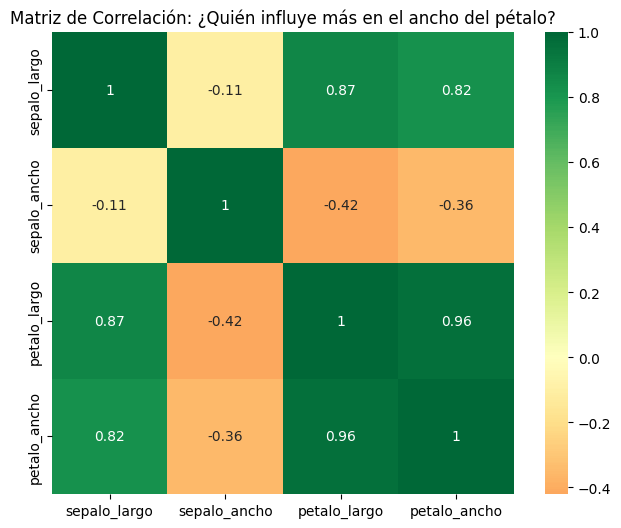

In [1519]:
# 1. Calculamos la correlación de las columnas numéricas
matriz_corr = dfIris.drop(columns=['especies']).corr()

# 2. Generamos el gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='RdYlGn', center=0, square=True)

plt.title('Matriz de Correlación: ¿Quién influye más en el ancho del pétalo?')
plt.show()

## Conclusiones parciales 1:

- Largo del pétalo: Según se observa en la matriz de correlación es la variable con mayor correlación.
- Largo del sépalo: Esta variable también tiene una alta correlación con el ancho del petalo.
- Ancho del sépalo: Esta variable tiene una correlación muy baja e incluso negativa.

Estas correlaciones analíticas tienen coherencia biológica, dado que los petalos crecen en ambas direcciones, a lo largo y a lo ancho. A su vez, los sépalos (cáliz, exterior) y pétalos (corola, interior) son hojas modificadas que forman el perianto que tiene una función de protección de los organos sexuales y de atracción de polinizadores y en el desarrollo temprano del capullo, los sépalos actúan como cobertura protectora del pétalo.

## Estudio de impacto de la dimensionalidad en los entrenamientos

Se procede a entrenar modelos con cantidades diferentes sucesivas de dimensiones y evaluar su rendimiento.



## Tres dimensiones

- Largo del pétalo
- Ancho del sépalo
- Largo del sépalo



### Particionamiento

In [1520]:
#X3 = dfIris.drop(['petalo_ancho', 'especies'], axis=1)
X3 = dfIris.drop(['petalo_ancho'], axis=1)
y = dfIris['petalo_ancho']

In [1521]:
# 2. División en entrenamiento y prueba
X_train3, X_test3, y_train3, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

In [1522]:
# Muestra el conteo absoluto de cada especie
print(X_test3['especies'].value_counts())

# O de forma más elegante para ver porcentajes (representatividad relativa)
print(X_test3['especies'].value_counts(normalize=True) * 100)
X_test3.drop('especies', axis=1, inplace=True)
X_train3.drop('especies', axis=1, inplace=True)

especies
Iris-virginica     11
Iris-setosa        10
Iris-versicolor     9
Name: count, dtype: int64
especies
Iris-virginica     36.666667
Iris-setosa        33.333333
Iris-versicolor    30.000000
Name: proportion, dtype: float64


### Búsqueda de K óptimo - Holdout - K vs MSE

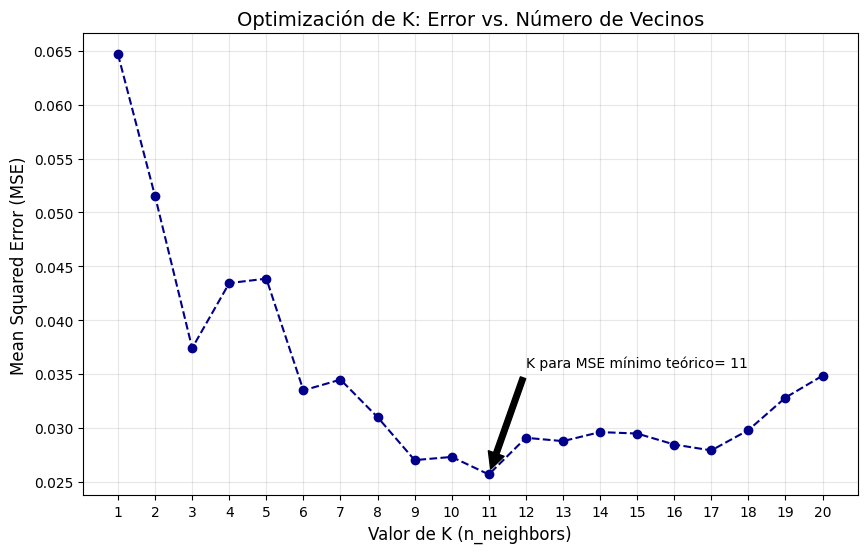

El valor de K teórico con MSE mínimo es: 11


In [1523]:
resultados_k3, best_k3_teorico = koptimomse(X_train3, X_test3, y_train3, y_test)

In [1524]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k3 = zona_estabilidad_continua(resultados_k3, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k3}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k3, min_residuo_3 = koptimo_residuos(zona_estable_k3, X_train3, X_test3, y_train3, y_test)

Zona encontrada con umbral 0.00125: [12, 13, 14, 15, 16, 17]
Rango de K en zona de estabilidad continua: [12, 13, 14, 15, 16, 17]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 12 | Prom residuos: 0.04138888888888881
K: 13 | Prom residuos: 0.03641025641025633
K: 14 | Prom residuos: 0.02761904761904755
K: 15 | Prom residuos: 0.025555555555555463
K: 16 | Prom residuos: 0.020624999999999994
K: 17 | Prom residuos: 0.019803921568627467

----------------

Clave (K) con residuo mínimo: 17
Valor del residuo mínimo: 0.019803921568627467


### Implementación de KNN Regresor

In [1525]:
knn_3 = KNeighborsRegressor(n_neighbors=best_k3)
knn_3.fit(X_train3, y_train3)

KNeighborsRegressor(n_neighbors=17)

### Predicciones

In [1526]:
y_pred3 = knn_3.predict(X_test3)

### Evaluación del modelo - Resultados (Graficando Línea de Identidad)

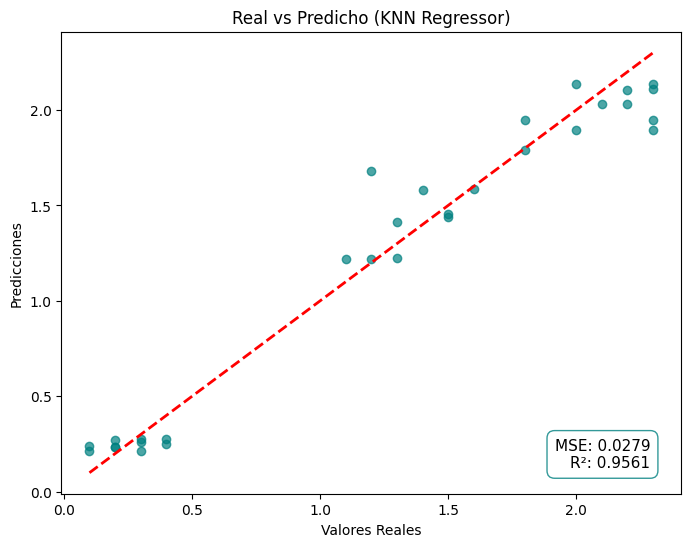

Mean Square Error: 0.027904267589388698
R^2: 0.9561015909551822


In [1527]:
mse3, r2_3 = regrapho(y_test, y_pred3)

### Histograma de Residuos

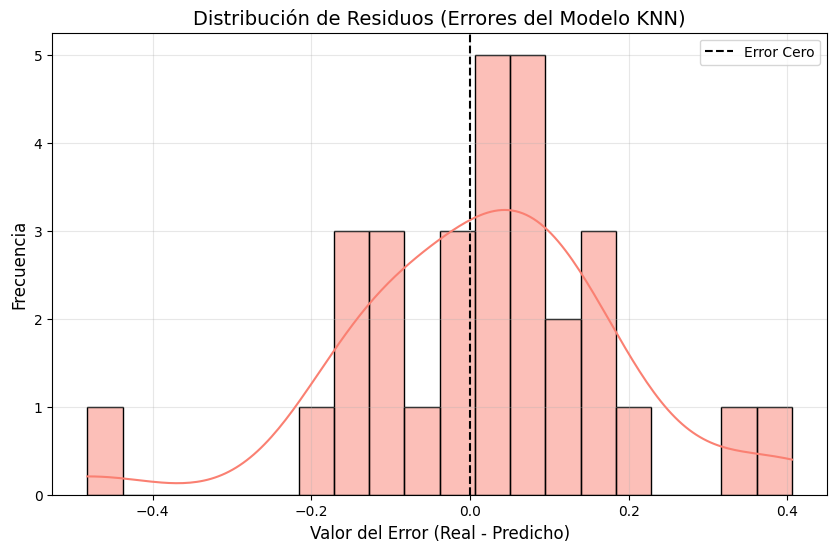

Sesgo promedio (Media de residuos): 0.0198


In [1528]:
graficar_histograma_residuos(y_test, y_pred3)

## Dos dimensiones


### Particionamiento A

Para el primer experimento con dos dimensiones tomamos una variable con fuerte correlación y otra de correlación débil con respecto a nuetra variable objetivo

- Largo del pétalo
- Ancho del sépalo

In [1529]:
X2a = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo'], axis=1)
nombres_2a = ['Largo del pétalo', 'Ancho del sépalo', 'Petalo ancho']

In [1530]:
# 2. División en entrenamiento y prueba
X_train2a, X_test2a, y_train2a, y_test = train_test_split(X2a, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

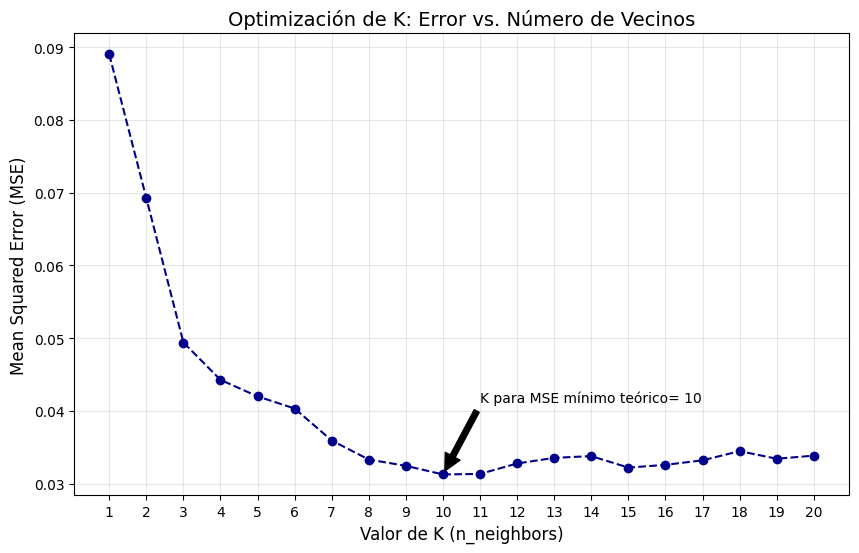

El valor de K teórico con MSE mínimo es: 10


In [1531]:
resultados_k2a, best_k2a_teorico = koptimomse(X_train2a, X_test2a, y_train2a, y_test)

In [1532]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k2a = zona_estabilidad_continua(resultados_k2a, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k2a}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k2a, min_residuo_2a = koptimo_residuos(zona_estable_k2a, X_train2a, X_test2a, y_train2a, y_test)

Zona encontrada con umbral 0.00125: [8, 9, 10, 11]
Rango de K en zona de estabilidad continua: [8, 9, 10, 11]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 8 | Prom residuos: 0.04958333333333331
K: 9 | Prom residuos: 0.044814814814814766
K: 10 | Prom residuos: 0.04566666666666662
K: 11 | Prom residuos: 0.04060606060606057

----------------

Clave (K) con residuo mínimo: 11
Valor del residuo mínimo: 0.04060606060606057


#### Implementación KNN Regressor

In [1533]:
knn_2a = KNeighborsRegressor(n_neighbors=best_k2a)
knn_2a.fit(X_train2a, y_train2a)

KNeighborsRegressor(n_neighbors=11)

#### Predicciones

In [1534]:
y_pred2a = knn_2a.predict(X_test2a)

#### Evaluación del modelo - Resultados (Graficando Línea de Identidad)



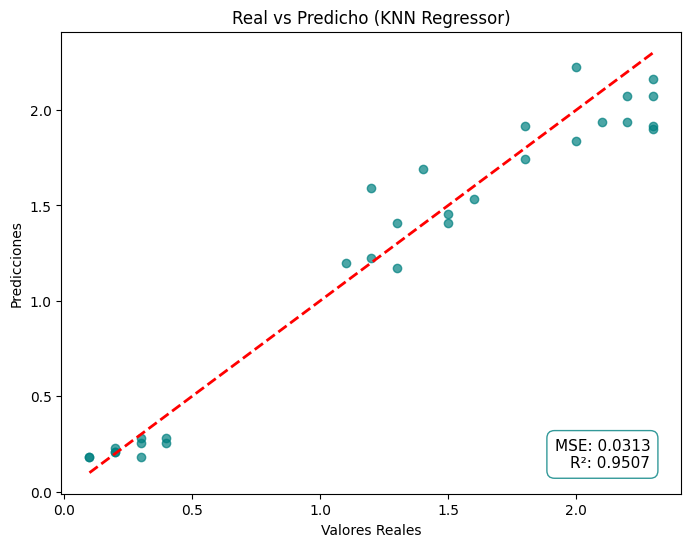

Mean Square Error: 0.03134435261707987
R^2: 0.9506897212757226


In [1535]:
mse2a, r2_2a = regrapho(y_test, y_pred2a)

#### Gráfico de Línea de Regresión

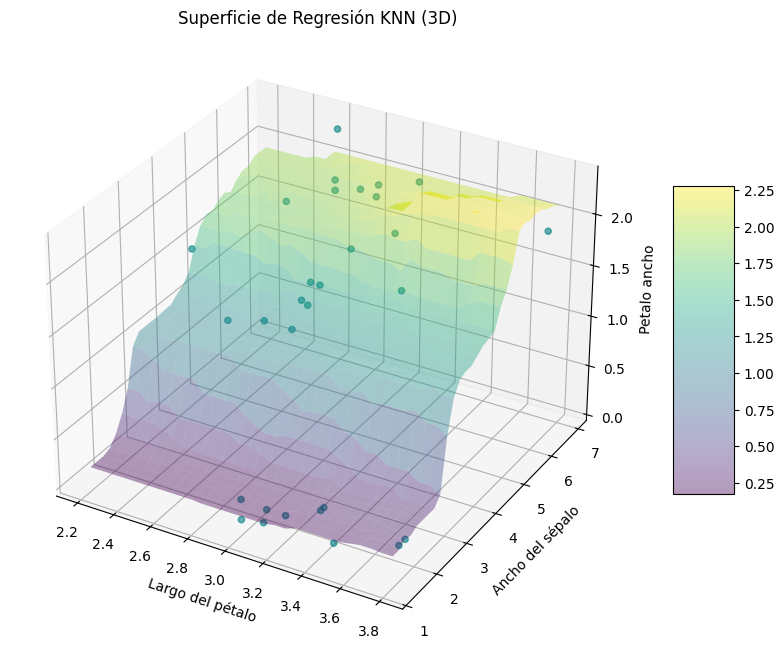

In [1536]:
graficar_superficie_3d_knn(knn_2a, X_test2a, y_test, nombres_2a)

#### Histograma de Residuos

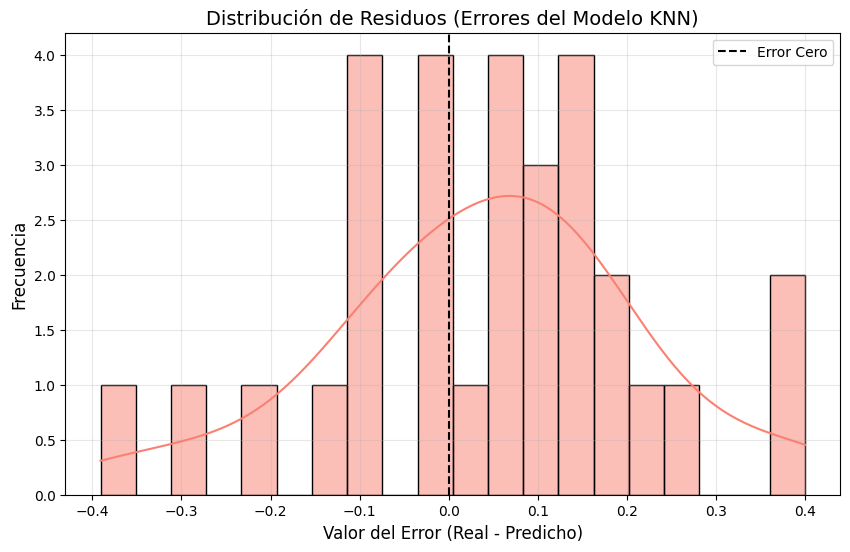

Sesgo promedio (Media de residuos): 0.0406


In [1537]:
graficar_histograma_residuos(y_test, y_pred2a)

### Particionamiento b

En el segundo experimento de dos dimensiones tomamos las dos variables que tienen fuerte correlación con nuestra variable objetivo

- Largo del pétalo
- Largo del sépalo

In [1538]:
X2b = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_ancho'], axis=1)
nombres_2b = ['Largo del pétalo', 'Largo del sépalo', 'Petalo ancho']

In [1539]:
# 2. División en entrenamiento y prueba
X_train2b, X_test2b, y_train2b, y_test = train_test_split(X2b, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

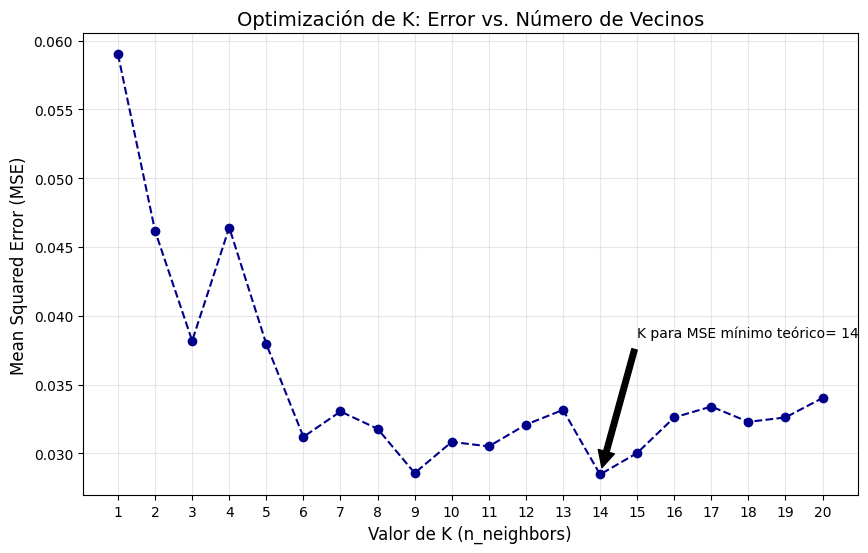

El valor de K teórico con MSE mínimo es: 14


In [1540]:
resultados_k2b, best_k2b = koptimomse(X_train2b, X_test2b, y_train2b, y_test)

In [1541]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k2b = zona_estabilidad_continua(resultados_k2b, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k2b}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k2b, min_residuo_2b = koptimo_residuos(zona_estable_k2b, X_train2b, X_test2b, y_train2b, y_test)

Zona encontrada con umbral 0.00125: [16, 17, 18, 19]
Rango de K en zona de estabilidad continua: [16, 17, 18, 19]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 16 | Prom residuos: 0.02062499999999999
K: 17 | Prom residuos: 0.023921568627450932
K: 18 | Prom residuos: 0.022037037037037004
K: 19 | Prom residuos: 0.02175438596491227

----------------

Clave (K) con residuo mínimo: 16
Valor del residuo mínimo: 0.02062499999999999


#### Implementación KNN Regressor

In [1542]:
knn_2b = KNeighborsRegressor(n_neighbors=best_k2b)
knn_2b.fit(X_train2b, y_train2b)

KNeighborsRegressor(n_neighbors=16)

#### Predicciones

In [1543]:
y_pred2b = knn_2b.predict(X_test2b)

#### Evaluación del modelo - Resultados

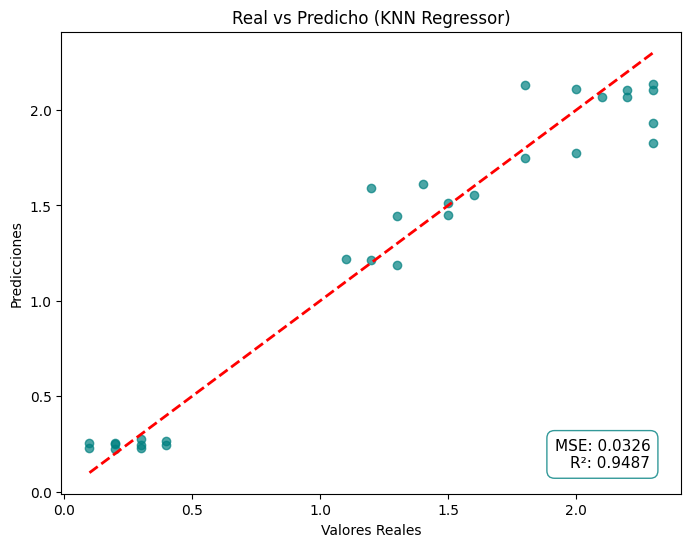

Mean Square Error: 0.03261588541666666
R^2: 0.948689372520058


In [1544]:
mse2b, r2_2b = regrapho(y_test, y_pred2b)


#### Gráfico de Línea de Regresión

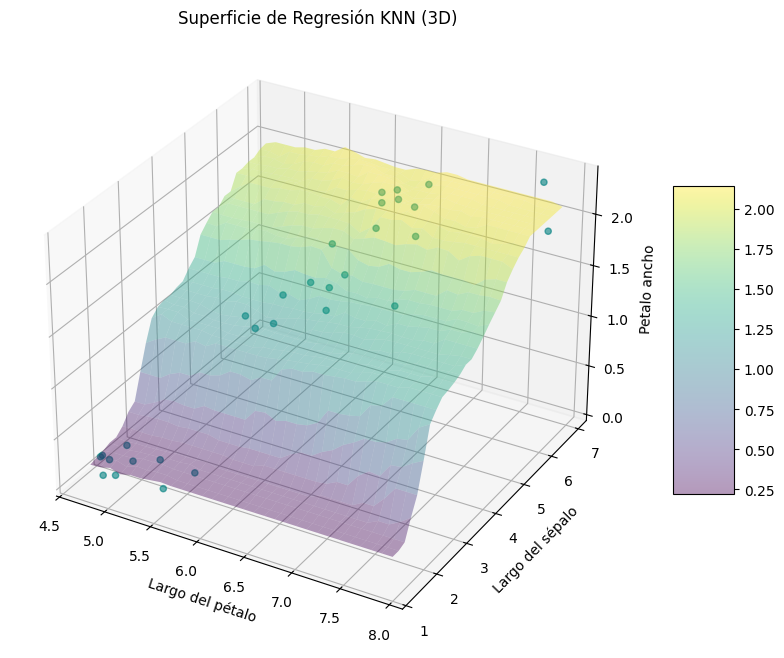

In [1545]:
graficar_superficie_3d_knn(knn_2b, X_test2b, y_test, nombres_2b)

#### Histograma de Residuos

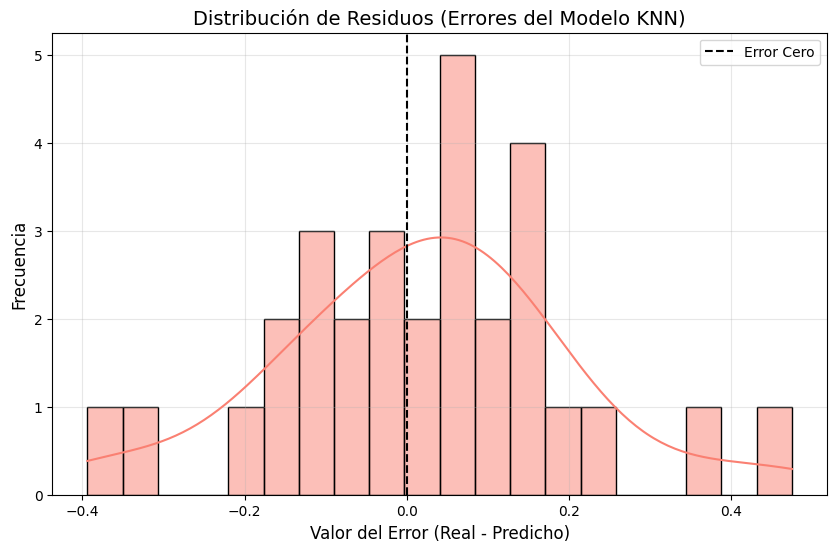

Sesgo promedio (Media de residuos): 0.0206


In [1546]:
graficar_histograma_residuos(y_test, y_pred2b)

La diferencia en los valores de $k$ (10 vs 14) se debe a cómo cambian las "vecindades" en el espacio multidimensional cuando cambiamos las variables.

 Experimento 1: Fuerte (+) y Negativa (-) ($k=10$)Al combinar una variable que "empuja" en la misma dirección que el objetivo (largo del pétalo) con una que "tira" en contra (ancho del sépalo), estamos creando un espacio con mucha estructura y contraste. El efecto: Las especies de flores quedan muy separadas entre sí. Como la separación es clara y hay "contraste" gracias a la variable negativa, el modelo encuentra el punto de equilibrio rápido. Por qué $k=10$: Necesitamos menos vecinos para promediar porque la estructura es robusta; hay menos ambigüedad en quién es vecino de quién.

 Experimento 2: Dos Fuertes (+) ($k=14$)Al usar dos variables con fuerte correlación (ej. largo del pétalo y largo del sépalo), tenemos redundancia. Ambas variables dicen casi lo mismo. El efecto: Esto crea lo que se llama "densidad" o "ruido de redundancia". Los puntos están muy pegados y las fronteras entre grupos de flores se vuelven más borrosas porque ambas variables escalan igual. Por qué $k=14$: Al haber más "amontonamiento" de datos que dicen lo mismo, el modelo necesita un $k$ más alto para suavizar la predicción. Un $k$ mayor ayuda a ignorar las pequeñas fluctuaciones de esos datos redundantes y a obtener un promedio más estable.

 En resumen:

 - Con contraste (+ y -): El modelo es más "decidido" y necesita mirar a menos vecinos para acertar.

 - Con redundancia (+ y +): El modelo se vuelve más "indeciso" porque los datos se parecen demasiado entre sí, y necesita ampliar el círculo de búsqueda ($k$ más alto) para estar seguro de la predicción.

### Particionamiento C

En el tercer experimento de dos dimensiones tomamos las variables

- Largo del sépalo
- Ancho del sépalo

La primera tiene una correlación fuerte con ancho del pétalo y ancho del sépalo que tiene una correlación débil y negativa.

In [1547]:
X2c = dfIris.drop(['petalo_largo', 'especies', 'petalo_ancho'], axis=1)
nombres_2c = ['Largo del sépalo', 'Ancho del sépalo', 'Petalo ancho']

In [1548]:
# 2. División en entrenamiento y prueba
X_train2c, X_test2c, y_train2c, y_test = train_test_split(X2c, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

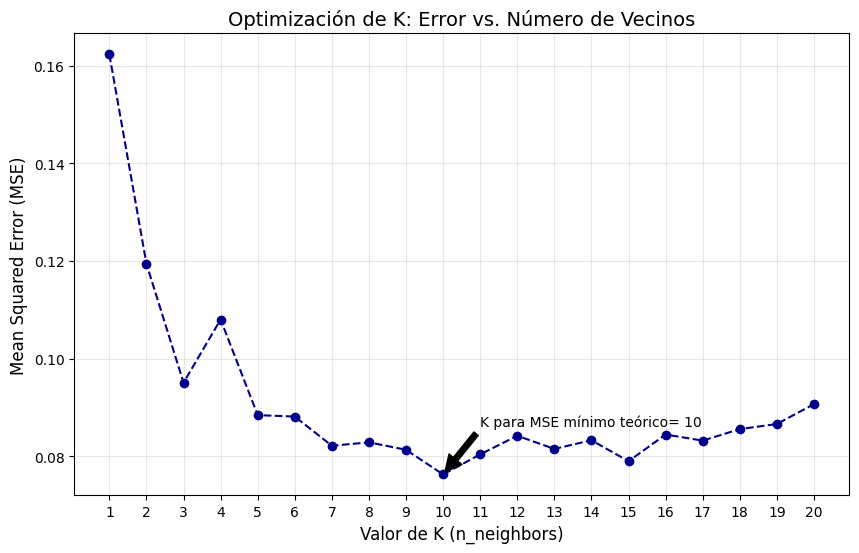

El valor de K teórico con MSE mínimo es: 10


In [1549]:
resultados_k2c, best_k2c = koptimomse(X_train2c, X_test2c, y_train2c, y_test)

In [1550]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_k2c = zona_estabilidad_continua(resultados_k2c, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_k2c}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k2c, min_residuo_2c = koptimo_residuos(zona_estable_k2c, X_train2c, X_test2c, y_train2c, y_test)

Umbral 0.00125 insuficiente (zona de tamaño 2). Reintentando...
Zona encontrada con umbral 0.0025: [16, 17, 18, 19]
Rango de K en zona de estabilidad continua: [16, 17, 18, 19]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 16 | Prom residuos: 0.0408333333333333
K: 17 | Prom residuos: 0.02960784313725488
K: 18 | Prom residuos: 0.029814814814814843
K: 19 | Prom residuos: 0.03245614035087719

----------------

Clave (K) con residuo mínimo: 17
Valor del residuo mínimo: 0.02960784313725488


#### Implementación KNN Regressor

In [1551]:
KNN_2c = KNeighborsRegressor(n_neighbors=best_k2c)
KNN_2c.fit(X_train2c, y_train2c)

KNeighborsRegressor(n_neighbors=17)

#### Predicciones

In [1552]:
y_pred2c = KNN_2c.predict(X_test2c)

#### Evaluación modelo - Resultados

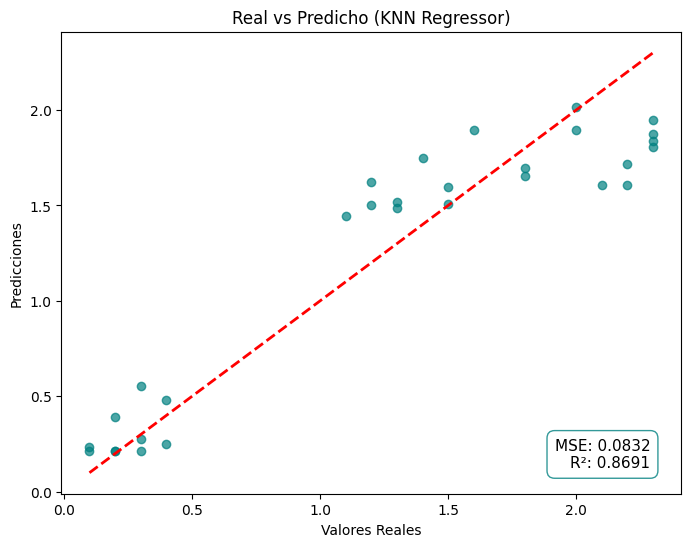

Mean Square Error: 0.08320530565167242
R^2: 0.8691031566947418


In [1553]:
mse2c, r2_2c = regrapho(y_test, y_pred2c)

#### Gráfico de Linea de Regresión

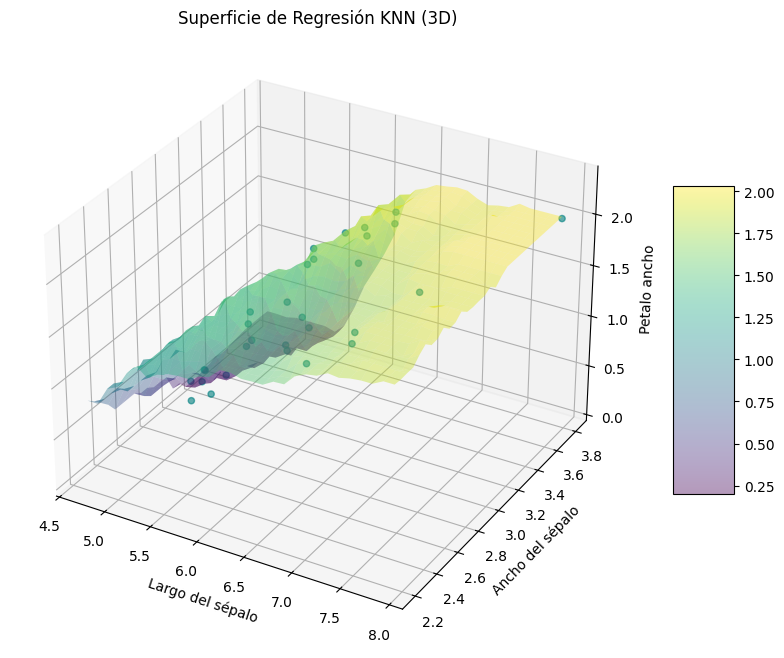

In [1554]:
graficar_superficie_3d_knn(KNN_2c, X_test2c, y_test, nombres_2c)

#### Histograma de Residuos

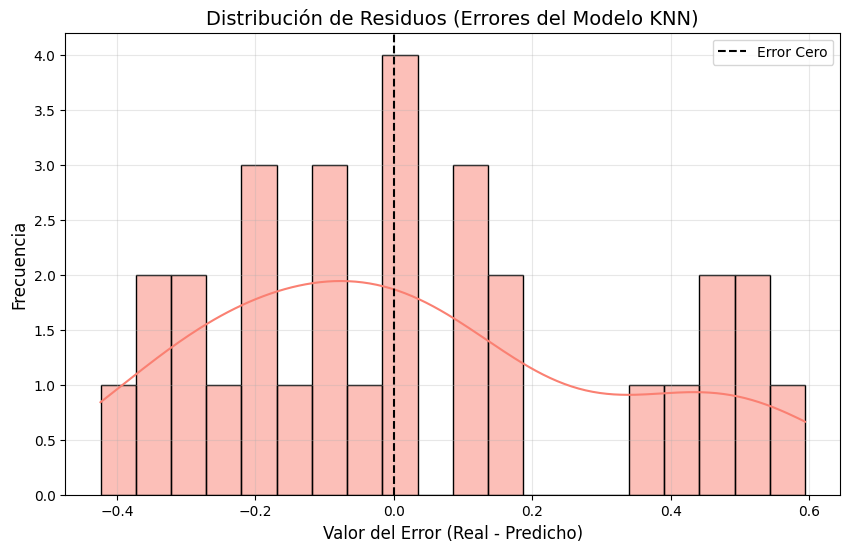

Sesgo promedio (Media de residuos): 0.0296


In [1555]:
graficar_histograma_residuos(y_test, y_pred2c)

## Una dimension


### Particionamiento a

En este primer experimento de una sola dimensión comenzamos primero con la variable de correlación más fuerte

- Largo del pétalo

In [1556]:
X1a = dfIris.drop(['petalo_ancho', 'especies', 'sepalo_largo', 'sepalo_ancho'], axis=1)
nombres_1a = ['Largo del pétalo', 'Petalo ancho']

In [1557]:
# 2. División en entrenamiento y prueba
X_train1a, X_test1a, y_train1a, y_test = train_test_split(X1a, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

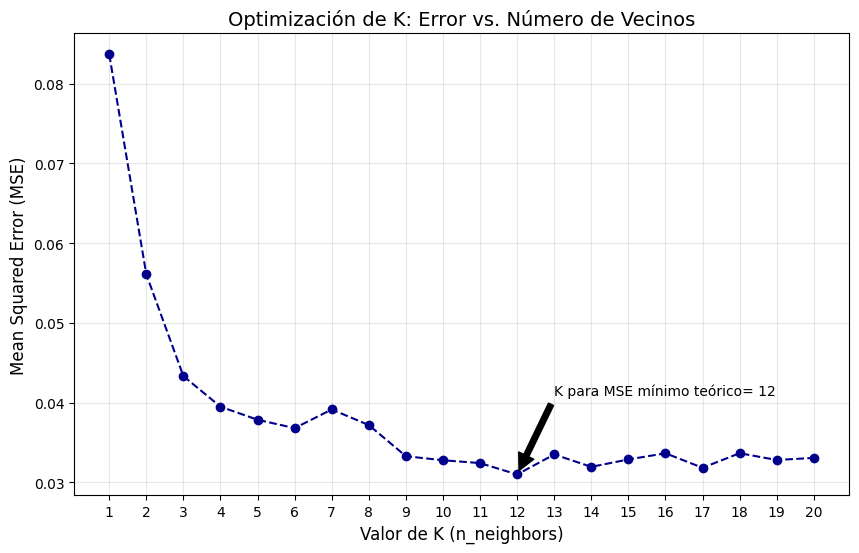

El valor de K teórico con MSE mínimo es: 12


In [1558]:
resultados_1a, best_k1a = koptimomse(X_train1a, X_test1a, y_train1a, y_test)

In [1559]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_1a = zona_estabilidad_continua(resultados_1a, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_1a}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k1a, min_residuo_1a = koptimo_residuos(zona_estable_1a, X_train1a, X_test1a, y_train1a, y_test)

Zona encontrada con umbral 0.00125: [9, 10, 11]
Rango de K en zona de estabilidad continua: [9, 10, 11]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 9 | Prom residuos: 0.030740740740740787
K: 10 | Prom residuos: 0.027333333333333334
K: 11 | Prom residuos: 0.03181818181818176

----------------

Clave (K) con residuo mínimo: 10
Valor del residuo mínimo: 0.027333333333333334


#### Implementación de KNN Regressor

In [1560]:
knn_1a = KNeighborsRegressor(n_neighbors=best_k1a)
knn_1a.fit(X_train1a, y_train1a)

KNeighborsRegressor(n_neighbors=10)

#### Predicciones

In [1561]:
y_pred1a = knn_1a.predict(X_test1a)

#### Evaluación del modelo - Resultados


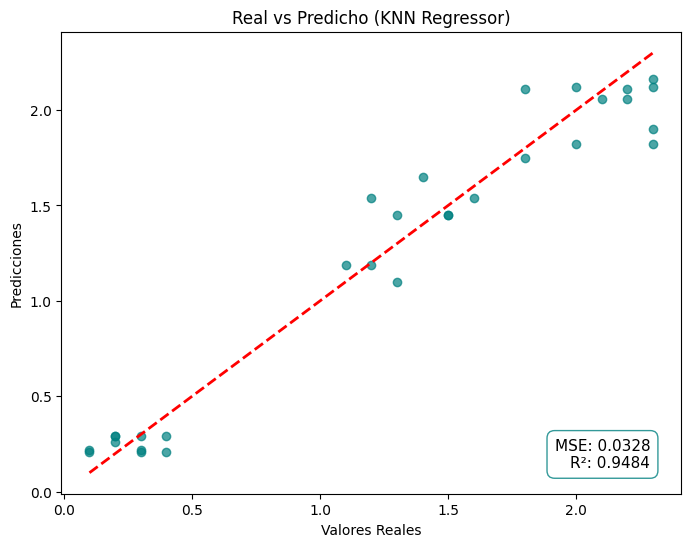

Mean Square Error: 0.03278666666666666
R^2: 0.9484207030362356


In [1562]:
mse1a, r2_1a = regrapho(y_test, y_pred1a)

#### Gráfico de Línea de Regresión

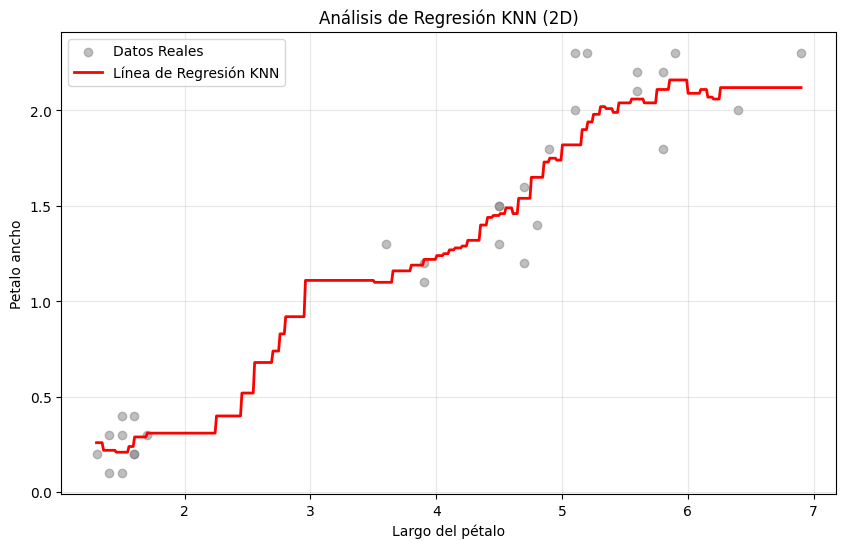

In [1563]:
graficar_linea_2d_knn(knn_1a, X_test1a, y_test, nombres_1a)

#### Histograma de Residuos

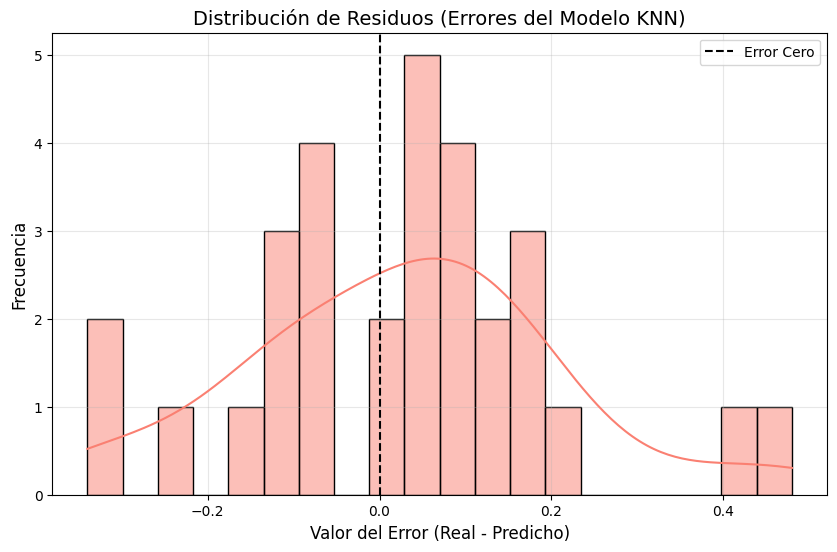

Sesgo promedio (Media de residuos): 0.0273


In [1564]:
graficar_histograma_residuos(y_test, y_pred1a)

### Particionamiento b
En el segundo experimento de una sola dimensión tomamos la segunda variable de correlación más fuerte

- Largo del sépalo

In [1565]:
X1b = dfIris.drop(['petalo_ancho', 'especies', 'petalo_largo', 'sepalo_ancho'], axis=1)
nombres_1b = ['Largo del sépalo', 'Sepalo largo']

In [1566]:
# 2. División en entrenamiento y prueba
X_train1b, X_test1b, y_train1b, y_test = train_test_split(X1b, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

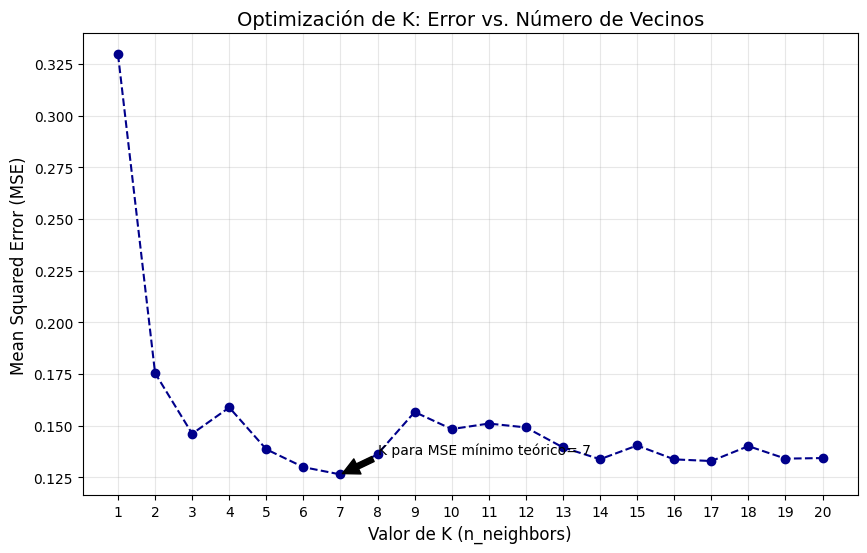

El valor de K teórico con MSE mínimo es: 7


In [1567]:
resultados_1b, best_k1b = koptimomse(X_train1b, X_test1b, y_train1b, y_test)

In [1568]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_1b = zona_estabilidad_continua(resultados_1b, umbral_p2p=0.00250)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_1b}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k1b, min_residuo_1b = koptimo_residuos(zona_estable_1b, X_train1b, X_test1b, y_train1b, y_test)

Umbral 0.0025 insuficiente (zona de tamaño 2). Reintentando...
Zona encontrada con umbral 0.005: [10, 11, 12]
Rango de K en zona de estabilidad continua: [10, 11, 12]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 10 | Prom residuos: -0.05866666666666674
K: 11 | Prom residuos: -0.057878787878787856
K: 12 | Prom residuos: -0.049166666666666685

----------------

Clave (K) con residuo mínimo: 10
Valor del residuo mínimo: -0.05866666666666674


#### Implementación de KNN Regressor

In [1569]:
knn_1b = KNeighborsRegressor(n_neighbors=best_k1b)
knn_1b.fit(X_train1b, y_train1b)

KNeighborsRegressor(n_neighbors=10)

#### Predicciones

In [1570]:
y_pred1b = knn_1b.predict(X_test1b)

#### Evaluación del modelo - Resultados


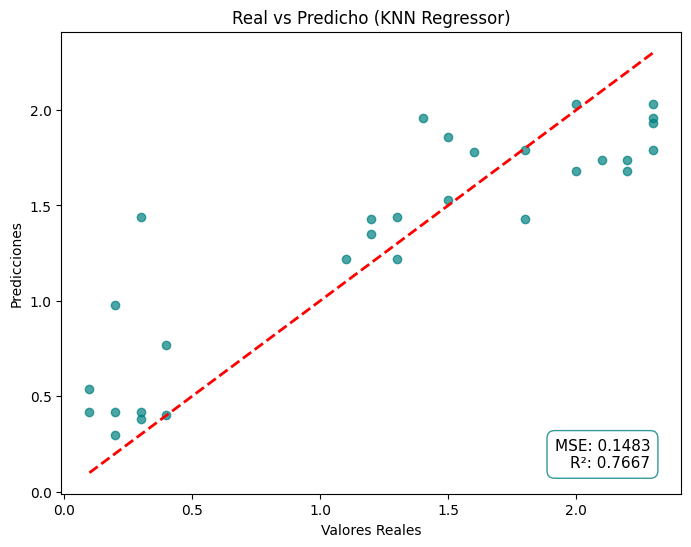

Mean Square Error: 0.1483266666666666
R^2: 0.7666555961474595


In [1571]:
mse1b, r2_1b = regrapho(y_test, y_pred1b)

#### Gráfico de Línea de Regresión

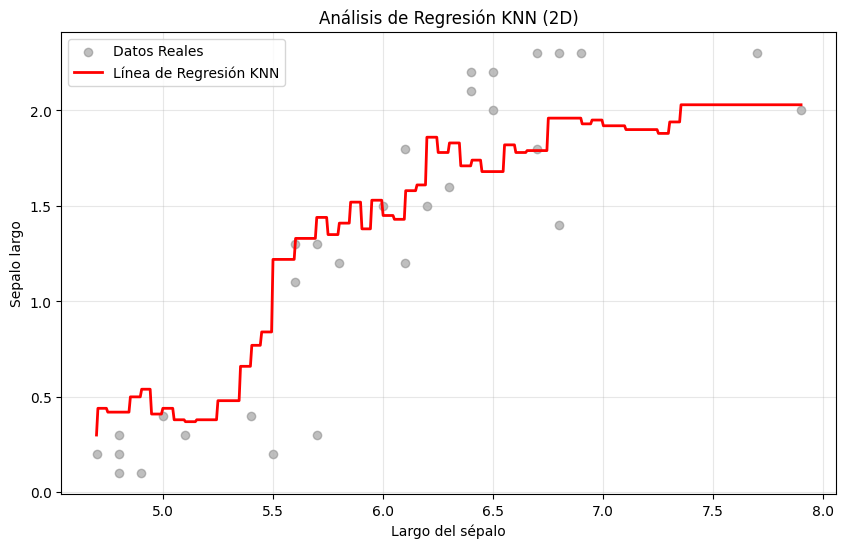

In [1572]:
graficar_linea_2d_knn(knn_1b, X_test1b, y_test, nombres_1b)

#### Histograma de Residuos

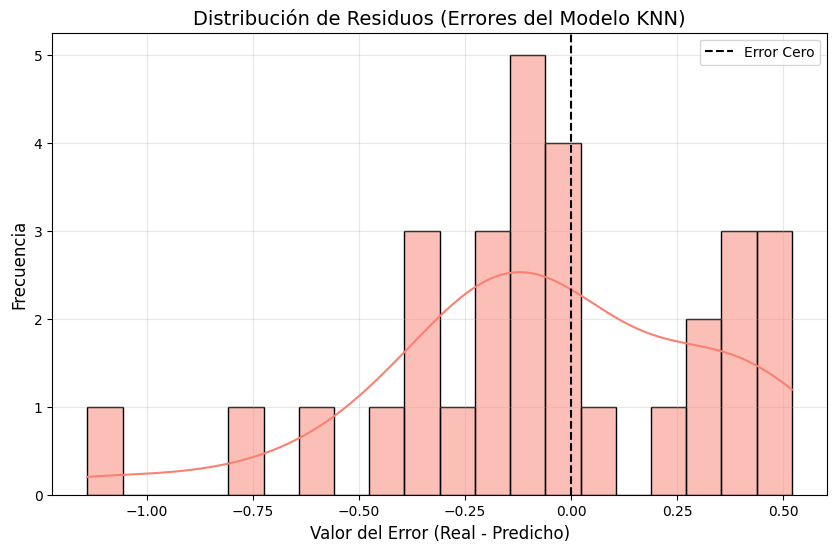

Sesgo promedio (Media de residuos): -0.0587


In [1573]:
graficar_histograma_residuos(y_test, y_pred1b)

### Particionamiento c
En el tercer experimento de una sola dimensión tomamos la variable de correlación débil

- Ancho del sépalo

In [1574]:
X1c = dfIris.drop(['petalo_ancho', 'especies', 'petalo_largo', 'sepalo_largo'], axis=1)
nombres_1c = ['Ancho del sépalo', 'Sepalo ancho']

In [1575]:
# 2. División en entrenamiento y prueba
X_train1c, X_test1c, y_train1c, y_test = train_test_split(X1c, y, test_size=0.2, random_state=42)

#### Búsqueda de K óptimo - Holdout - K vs MSE

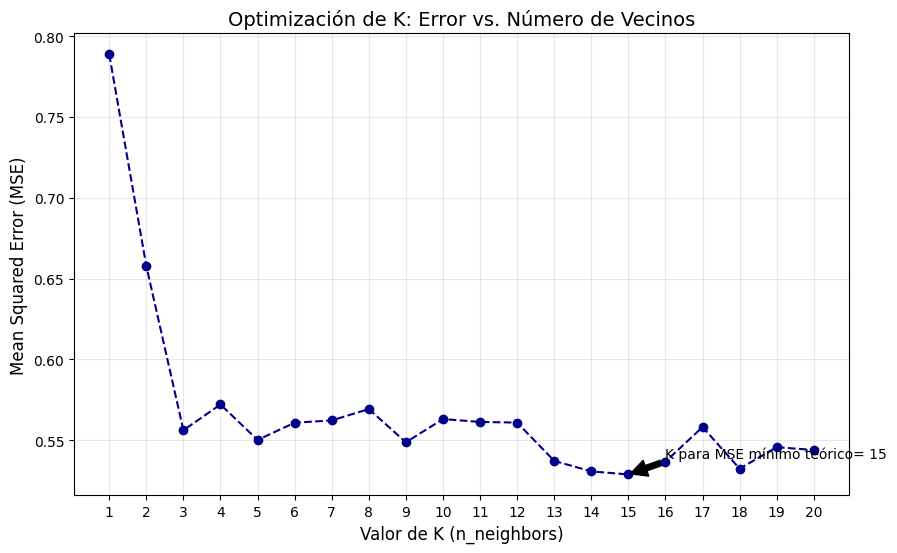

El valor de K teórico con MSE mínimo es: 15


In [1576]:
resultados_1c, best_k1c = koptimomse(X_train1c, X_test1c, y_train1c, y_test)

In [1577]:
# --- Ejecución ---
# Ajusta el umbral_p2p según la escala de tu MSE (ej. 0.0004 o 0.0005)
zona_estable_1c = zona_estabilidad_continua(resultados_1c, umbral_p2p=0.00125)
print(f"Rango de K en zona de estabilidad continua: {zona_estable_1c}")

print("\n--------------------\n")
print("Promedio de residuos para cada K de la zona de estabilidad\n")

best_k1a, min_residuo_1a = koptimo_residuos(zona_estable_1c, X_train1c, X_test1c, y_train1c, y_test)

Umbral 0.00125 insuficiente (zona de tamaño 2). Reintentando...
Zona encontrada con umbral 0.0025: [10, 11, 12]
Rango de K en zona de estabilidad continua: [10, 11, 12]

--------------------

Promedio de residuos para cada K de la zona de estabilidad

K: 10 | Prom residuos: -0.08733333333333333
K: 11 | Prom residuos: -0.0493939393939394
K: 12 | Prom residuos: -0.0866666666666666

----------------

Clave (K) con residuo mínimo: 10
Valor del residuo mínimo: -0.08733333333333333


#### Implementación de KNN Regressor

In [1578]:
knn_1c = KNeighborsRegressor(n_neighbors=best_k1c)
knn_1c.fit(X_train1c, y_train1c)

KNeighborsRegressor(n_neighbors=15)

#### Predicciones

In [1579]:
y_pred1c = knn_1c.predict(X_test1c)

#### Evaluación del modelo - Resultados

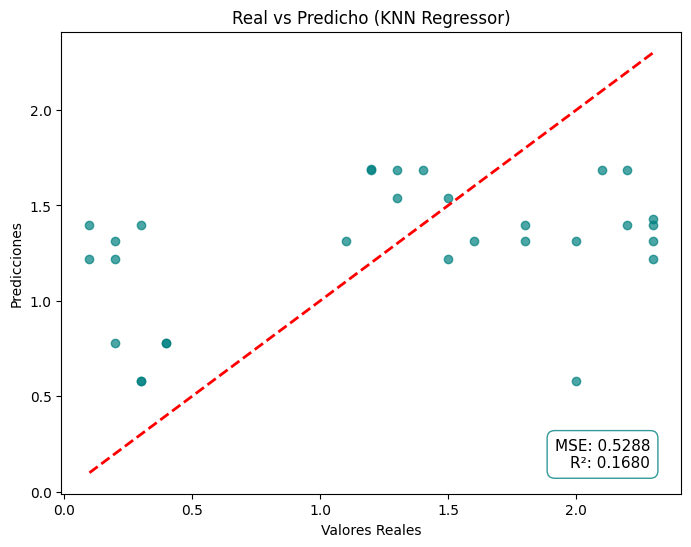

Mean Square Error: 0.5288414814814815
R^2: 0.16803766307166124


In [1580]:
mse1c, r2_1c = regrapho(y_test, y_pred1c)

#### Gráfico de Línea de Regresión

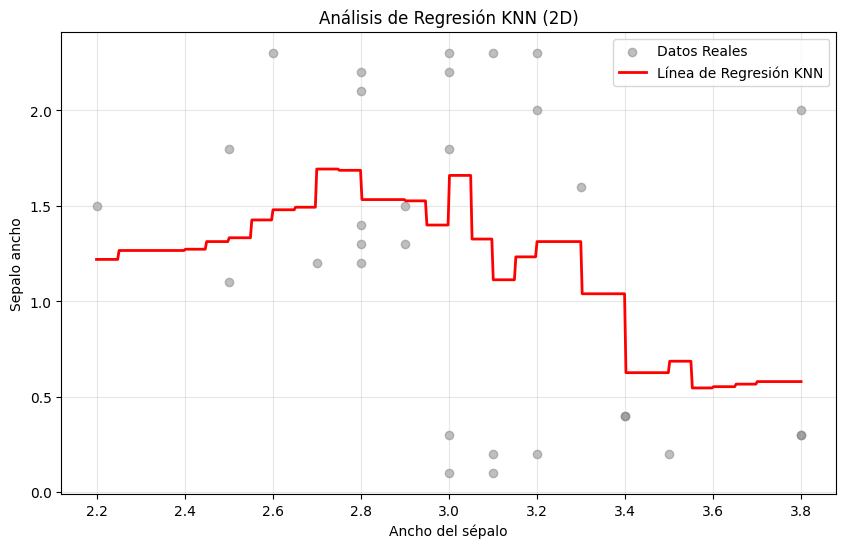

In [1581]:
graficar_linea_2d_knn(knn_1c, X_test1c, y_test, nombres_1c)

#### Histograma de Residuos

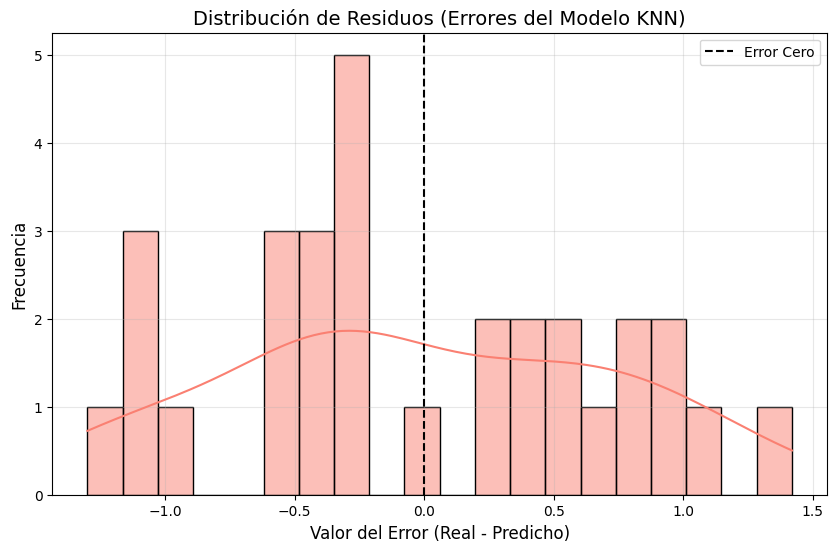

Sesgo promedio (Media de residuos): -0.0191


In [1582]:
graficar_histograma_residuos(y_test, y_pred1c)

# Comparaciones

A fin de observar el impacto de la exploración de K óptimos, se procede a obtener los valores de R^2 y MSE para todas las dimensionalidades usando el valor teórico de K acorde al tamaño del dataset (K = 12).

Con todos los datos se crea una tabla para poder realizar las comparaciones correspondientes.

In [1583]:
# entrenamos los modelos con K teorico = 12
knn = KNeighborsRegressor(n_neighbors=12)

knn.fit(X_train3, y_train3)
y_pred_12n_3 = knn.predict(X_test3)
mse_12n_3, r2_12n_3 = regre(y_test, y_pred_12n_3)

knn.fit(X_train2a, y_train2a)
y_pred_12n_2a = knn.predict(X_test2a)
mse_12n_2a, r2_12n_2a = regre(y_test, y_pred_12n_2a)

knn.fit(X_train2b, y_train2b)
y_pred_12n_2b = knn.predict(X_test2b)
mse_12n_2b, r2_12n_2b = regre(y_test, y_pred_12n_2b)

knn.fit(X_train2c, y_train2c)
y_pred_12n_2c = knn.predict(X_test2c)
mse_12n_2c, r2_12n_2c = regre(y_test, y_pred_12n_2c)

knn.fit(X_train1a, y_train1a)
y_pred_12n_1a = knn.predict(X_test1a)
mse_12n_1a, r2_12n_1a = regre(y_test, y_pred_12n_1a)

knn.fit(X_train1b, y_train1b)
y_pred_12n_1b = knn.predict(X_test1b)
mse_12n_1b, r2_12n_1b = regre(y_test, y_pred_12n_1b)

knn.fit(X_train1c, y_train1c)
y_pred_12n_1c = knn.predict(X_test1c)
mse_12n_1c, r2_12n_1c = regre(y_test, y_pred_12n_1c)

# Creamos un diccionario con los resultados

data = {
    "Dimensiones": ["3 dimensiones", "2 dimensiones-A", "2 dimensiones-B",  "2 dimensiones-C", "1 dimensión-A", "1 dimensión-B", "1 dimensión-C"],
    "| ": ['| '] * 7,
    "K optimo": [best_k3, best_k2a, best_k2b, best_k2c, best_k1a, best_k1b, best_k1c],
    " ": [' '] * 7,
    "MSE": [mse3, mse2a, mse2b, mse2c, mse1a, mse1b, mse1c],
    "R² Score": [r2_3, r2_2a, r2_2b, r2_2c, r2_1a, r2_1b, r2_1c],
    " | ": ['| '] * 7,
    "K teórico": ['12 '] * 7,
    " MSE": [mse_12n_3, mse_12n_2a, mse_12n_2b, mse_12n_2c, mse_12n_1a, mse_12n_1b, mse_12n_1c],
    " R² Score": [r2_12n_3, r2_12n_2a, r2_12n_2b, r2_12n_2c, r2_12n_1a, r2_12n_1b, r2_12n_1c]
}

# Se redondean los valores de 'data' a 4 posiciones luego de la coma
data_formateada = {
    key: [round(val, 4) if isinstance(val, float) else val for val in values]
    for key, values in data.items()
}

# Creamos el DataFrame
df_comparativo = pd.DataFrame(data_formateada)

# Imprimimos con un formato estético
print("TABLA COMPARATIVA DE MODELOS")
print("-" * 80)
print(df_comparativo.to_string(index=False))
print("-" * 80)

# Opcional: Si quieres resaltar cuál es el mejor (menor MSE)
mejor_modelo = df_comparativo.loc[df_comparativo['MSE'].idxmin(), 'Dimensiones']
peor_modelo = df_comparativo.loc[df_comparativo['MSE'].idxmax(), 'Dimensiones']
print(f"El mejor desempeño general lo tiene el modelo: {mejor_modelo}")
print(f"El peor desempeño general lo tiene el modelo: {peor_modelo}")

# Imprimir el nombre del modelo que con K teórico es mejor que con K óptimo
mejor_modelo_teorico = df_comparativo.loc[df_comparativo[' MSE'].idxmin(), 'Dimensiones']


TABLA COMPARATIVA DE MODELOS
--------------------------------------------------------------------------------
    Dimensiones |   K optimo      MSE  R² Score  |  K teórico    MSE   R² Score
  3 dimensiones |         17   0.0279    0.9561  |        12  0.0291     0.9543
2 dimensiones-A |         11   0.0313    0.9507  |        12  0.0328     0.9484
2 dimensiones-B |         16   0.0326    0.9487  |        12  0.0321     0.9495
2 dimensiones-C |         17   0.0832    0.8691  |        12  0.0842     0.8675
  1 dimensión-A |         10   0.0328    0.9484  |        12  0.0310     0.9512
  1 dimensión-B |         10   0.1483    0.7667  |        12  0.1491     0.7654
  1 dimensión-C |         15   0.5288    0.1680  |        12  0.5609     0.1176
--------------------------------------------------------------------------------
El mejor desempeño general lo tiene el modelo: 3 dimensiones
El peor desempeño general lo tiene el modelo: 1 dimensión-C


In [1586]:
# 1. Identificamos los casos donde el MSE teórico es menor al MSE óptimo
# Nota: Asegúrate de usar los nombres exactos de tus columnas (incluyendo espacios)
casos_mejor_teorico = df_comparativo[df_comparativo[' MSE'] < df_comparativo['MSE']]

print("MODELOS DONDE K TEÓRICO SUPERÓ A K ÓPTIMO")
print("-" * 60)

if not casos_mejor_teorico.empty:
    for index, row in casos_mejor_teorico.iterrows():
        diff = row['MSE'] - row[' MSE']
        print(f"Modelo: {row['Dimensiones']}")
        print(f"  > MSE Óptimo ({row['K optimo']}): {row['MSE']:.4f}")
        print(f"  > MSE Teórico (12): {row[' MSE']:.4f}")
        print(f"  > Mejora del teórico: {diff:.4f}")
        print("-" * 30)
else:
    print("En ninguna combinación el K teórico fue más performante.")

# 2. Guardar los nombres en una lista si necesitas usarlos luego
nombres_modelos_mejor_teorico = casos_mejor_teorico['Dimensiones'].tolist()

MODELOS DONDE K TEÓRICO SUPERÓ A K ÓPTIMO
------------------------------------------------------------
Modelo: 2 dimensiones-B
  > MSE Óptimo (16): 0.0326
  > MSE Teórico (12): 0.0321
  > Mejora del teórico: 0.0005
------------------------------
Modelo: 1 dimensión-A
  > MSE Óptimo (10): 0.0328
  > MSE Teórico (12): 0.0310
  > Mejora del teórico: 0.0018
------------------------------


In [1587]:
# 1. Identificamos los casos donde el R² Score obtenido con K teórico es menor al R² Score óptimo
casos_mejor_teorico = df_comparativo[df_comparativo[' R² Score'] > df_comparativo['R² Score']]

print("Modelos en que R² Score con K teórico superó al K óptimo")
print("-" * 60)

if not casos_mejor_teorico.empty:
    for index, row in casos_mejor_teorico.iterrows():
        diff = row[' R² Score'] - row['R² Score']
        print(f"Modelo: {row['Dimensiones']}")
        print(f"  > R² Score con K Óptimo ({row['K optimo']}): {row['R² Score']:.4f}")
        print(f"  > R² Score con K Teórico (12): {row[' R² Score']:.4f}")
        print(f"  > Mejora del teórico: {diff:.4f}")
        print("-" * 30)
else:
    print("En ninguna combinación el K teórico fue más performante.")

# 2. Guardar los nombres en una lista si necesitas usarlos luego
nombres_modelos_mejor_teorico = casos_mejor_teorico['Dimensiones'].tolist()

Modelos en que R² Score con K teórico superó al K óptimo
------------------------------------------------------------
Modelo: 2 dimensiones-B
  > R² Score con K Óptimo (16): 0.9487
  > R² Score con K Teórico (12): 0.9495
  > Mejora del teórico: 0.0008
------------------------------
Modelo: 1 dimensión-A
  > R² Score con K Óptimo (10): 0.9484
  > R² Score con K Teórico (12): 0.9512
  > Mejora del teórico: 0.0028
------------------------------


# Conclusiones grales:

**Sobre las correlaciones**
Las observaciones sobre las correlaciones entre las diferentes variables de este dataset sobre largo y ancho de sepalos y petalos mantienen coherencia biológica, ya que los petalos así como los sepalos, crecen en ambas direcciones, a lo largo y a lo ancho.
Los sépalos (cáliz, exterior) y pétalos (corola, interior) son hojas modificadas que forman el perianto que tiene una función de protección de los organos sexuales y de atracción de polinizadores.
Las correlación Sépalo Largo vs. Pétalo Largo (0.87) y Pétalo Ancho (0.82) dan cuenta del desarrollo conjunto del perianto en la especie Iris ya que si el sépalo (que protege al capullo) es grande, biológicamente es esperable que el pétalo que contiene también lo sea.
Resulta destacable, sin embargo, que el ancho del sépalo tiene correlaciones negativas o muy débiles con el resto (-0.11, -0.42, -0.36). Esto sugiere que, en la familia Iris, el ancho del sépalo sigue una lógica que en algún punto del desarrollo se vuelve distinta a las otras tres variables.

**En cuanto a la metodología empleada para la elección de K**
Los resultados indican que la selección analítica del K óptimo devuelve mejores resultados que superan o igualan los valores de R² obtenidos con el K teórico a nivel de la segunda y tercera cifra significativa. Sin embargo, existen dos excepciones. En la primera, la diferencia es en la tercer cifra significativa con lo cual resulta prácticamente despreciable y en el otro se trata de una diferencia de 3 milésimas que tiene impacto en la segunda cifra significativa. Estos hallazgos consideramos que resultan una validación del método analítico propuesto e invitan a una discusión que se comenta en la sección apropiada.
(Meto: euclidiana (Minkowski p=2 por defecto en Scikit learn)
**El problema de la multi-colinealidad en la multi-dimensinalidad:**
Una de las hipotesis fue que al entrenar el dataset con las tres dimensiones existiendo dos con alta colinealidad que son largo del pétalo y largo del sépalo, existía un peligro de multi-colinealidad que hiciera que la información se vuelva redundante y el cálculo de la distancia se vea "arrastrado" doblemente por la misma tendencia subyacente y el algoritmo resultara menos sensible a variables de menor correlación (como el ancho del sépalo) y la predicción termine dependiendo excesivamente de la longitud. Los resultados indicaron lo contrario y la regresión lineal obtenida con 3-dimensiones fue la mejor de todas, seguida por el modelo 2-dimensiones-A, 2-dimensiones-B y 1-dimensión-A, incluyendo todos ellos la variable pétalo-largo.
Por el contrario los modelos que no incluyeron la variable pétalo-largo, la de mayor correlación con pétalo-ancho, obtuvieron resultados menos performantes haciendo evidente lo adelantado por la matriz de correlación respecto a la fuerte correlación entre pétalo-largo y pétalo-ancho.

**Discusión:**
La excepción de correlación de la dimensión sepalo ancho con las demás, podría estar principalmente ligada a la anatomia de otra estructura vegetal no observada en este dataset. También es posible que esta relación se encuentre gobernada por las etapas de la floración y que sea un punto de la pre-antesis o el inicio de la antesis misma lo que determine un punto de inflexión en el comportamiento de la correlación con las demás dimensiones. Sin embargo, la falta de datos sobre dimensiones de otras estructuras y del punto del desarrollo en el cual se realizaron las observaciones capturadas en este dataset impide determinalo sin incluir otras fuentes de datos.

**Sobre la colinealidad y la búsqueda del K óptimo**
Aunque la colinealidad existe, los resultados indican que los modelos se beneficiaron de esta redundancia informativa para ganar estabilidad en la predicción al emplear KNN que mide distancia posiblemente actúando como un refuerzo de la señal frente al ruido.

Finalmente, la diferencia marginal entre el K óptimo analítico y el K teórico demuestra que, para este dataset, el costo computacional de la optimización no ofrece un retorno significativo. Esto se debe, probablemente, a la naturaleza altamente balanceada y la clara separabilidad de las clases en el dataset IrisLa diferencia de resultados obtenidos con el uso de un K óptimo respecto de uno teórico es indicativo de que el esfuerzo involucrado para diferenciar uno de otro no resulta relevante para este dataset. Posiblemente sea causa de ambas cuestiones la naturaleza tan balanceada del dataset Iris.
